# 长川科技技术指标计算实验

本 notebook 按 `task02_indicator_lab/indicator_lab_spec.md` (v1.1) 实现, 用长川科技 (300604.SZ) 近一年日线数据计算 **RSI / MACD / 布林带 / ATR** 四项技术指标。

**严格遵守 4 项关键设计决策 (见 spec 第 12 节):**
- **D1**: MACD 柱 = DIF − DEA (不乘 2)
- **D2**: Wilder 平滑用 `ewm(alpha=1/n)` (非 `ewm(span=N)`)
- **D3**: 布林带用 `ddof=0` (总体标准差)
- **D4**: warmup 期保留 NaN (不填 0 / 不 ffill / 不 dropna)

---

## Cell 1 — 全局配置

调参只改这里。

In [1]:
# ============ 全局配置 ============
PARAMS = {
    "rsi_period": 14,
    "macd_fast": 12, "macd_slow": 26, "macd_signal": 9,
    "bb_window": 20, "bb_std": 2,
    "atr_period": 14,
}
DATA_PATH = "../../data/processed/300604.SZ_daily_20250718_20260718.csv"
OUTPUT_DIR = "../outputs"
CHART_DIR = "../charts"
TS_CODE = "300604.SZ"
NAME = "长川科技"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHART_DIR, exist_ok=True)
print("配置已加载:", PARAMS)
print("数据路径:", DATA_PATH)


配置已加载: {'rsi_period': 14, 'macd_fast': 12, 'macd_slow': 26, 'macd_signal': 9, 'bb_window': 20, 'bb_std': 2, 'atr_period': 14}
数据路径: ../../data/processed/300604.SZ_daily_20250718_20260718.csv


## Cell 2 — 环境与依赖导入

依赖: pandas, numpy, matplotlib (不依赖 talib, 手写实现以体现计算过程)。

可视化约定:
- **A股惯例: 涨红跌绿** (up=`#D85A30`, down=`#1D9E75`)
- 中文字体: Arial Unicode MS (macOS 自带)
- 浅色背景

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os, json
from datetime import datetime

# matplotlib 中文与样式
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.facecolor'] = '#FFFFFF'
plt.rcParams['axes.facecolor'] = '#F1EFE8'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#D3D1C7'
plt.rcParams['grid.alpha'] = 0.5

# A股色板: 涨红跌绿
UP_COLOR = '#D85A30'      # 涨/正
DOWN_COLOR = '#1D9E75'    # 跌/负
MID_COLOR = '#185FA5'     # 中轨/主线
BAND_COLOR = '#AFA9EC'    # 通道填充
ACCENT = '#534AB7'        # 强调

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
print("环境就绪")


环境就绪


## Cell 3 — 数据加载与预览

数据来自 task01 的取数脚本 (`fetch_stock_data.py`), 已通过校验 (validation: PASS)。字段含义见 `stock_data_spec.md` 第 2 节。

In [3]:
# 读取 CSV (utf-8-sig 含 BOM)
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

# 日期转 datetime, 设为 index, 升序
df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
df = df.sort_values('trade_date').set_index('trade_date')

# 数值列强制 float64
num_cols = ['open','high','low','close','pre_close','change','pct_chg','vol','amount']
df[num_cols] = df[num_cols].astype('float64')

print(f"行数: {len(df)}")
print(f"日期范围: {df.index[0].date()} ~ {df.index[-1].date()}")
df.head()


行数: 242
日期范围: 2025-07-18 ~ 2026-07-17


,ts_code,open,high,low,close,pre_close,change,pct_chg,vol,amount
trade_date,,,,,,,,,,
2025-07-18,300604.SZ,44.66,45.00,44.17,44.58,44.79,-0.21,-0.4689,147739.42,657149.463
2025-07-21,300604.SZ,44.59,44.65,44.20,44.38,44.58,-0.20,-0.4486,114860.42,510059.221
2025-07-22,300604.SZ,43.83,44.36,42.71,43.92,44.38,-0.46,-1.0365,247590.97,1081221.758
2025-07-23,300604.SZ,43.96,45.30,43.94,45.02,43.92,1.10,2.5046,336869.96,1512868.585
2025-07-24,300604.SZ,45.16,45.68,44.75,45.13,45.02,0.11,0.2443,233711.60,1055146.707


In [4]:
df.info()
df.describe().round(2)


<class 'pandas.DataFrame'>
DatetimeIndex: 242 entries, 2025-07-18 to 2026-07-17
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ts_code    242 non-null    str    
 1   open       242 non-null    float64
 2   high       242 non-null    float64
 3   low        242 non-null    float64
 4   close      242 non-null    float64
 5   pre_close  242 non-null    float64
 6   change     242 non-null    float64
 7   pct_chg    242 non-null    float64
 8   vol        242 non-null    float64
 9   amount     242 non-null    float64
dtypes: float64(9), str(1)
memory usage: 20.8 KB


,open,high,low,close,pre_close,change,pct_chg,vol,amount
count,242.00,242.00,242.00,242.00,242.00,242.00,242.00,242.00,242.00
mean,130.65,135.67,126.69,131.33,130.36,0.97,0.87,334417.55,4281292.61
std,76.02,80.09,72.05,76.20,75.81,8.35,4.74,191195.58,3015876.57
min,43.50,44.15,42.71,43.44,43.44,-32.21,-9.65,93685.90,412038.13
25%,79.06,80.98,77.98,79.64,79.46,-1.74,-1.99,208904.52,2049625.76
50%,121.04,124.46,117.27,120.90,120.75,0.27,0.39,306743.48,3354288.23
75%,150.24,153.50,147.05,151.52,150.10,3.36,2.96,389394.20,5719620.35
max,379.60,395.00,349.18,374.00,374.00,56.78,20.00,1265321.40,14616432.99


## Cell 4 — 数据质量检查

检查项:
1. 行数 ≥ 60 (保证 warmup 后有足够样本)
2. `high ≥ low ≥ 0` (价格关系合理)
3. `close` 无 NaN / 无负值
4. 画 close 走势预览

质量检查通过: 242 行, 日期 2025-07-18 ~ 2026-07-17


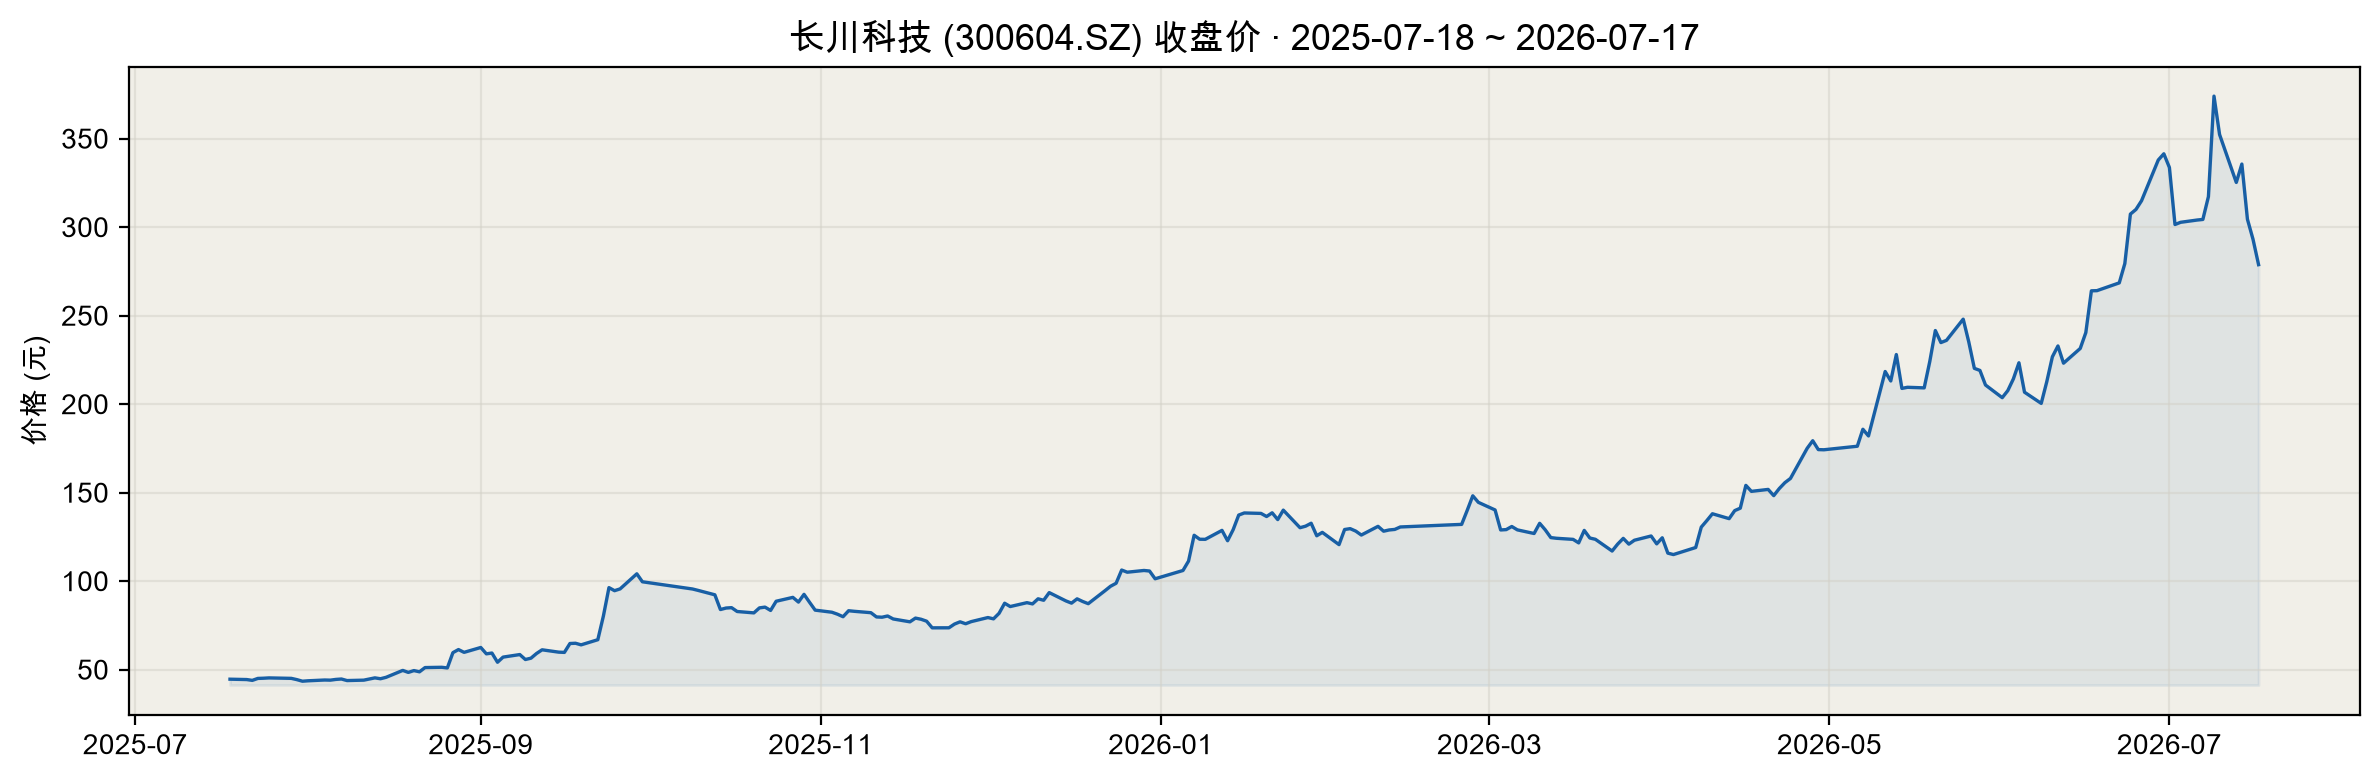

In [5]:
# 数据质量断言
assert len(df) >= 60, f"行数不足: {len(df)}"
assert (df['high'] >= df['low']).all(), "存在 high < low"
assert (df[['open','high','low','close']] >= 0).all().all(), "存在负价"
assert df['close'].isna().sum() == 0, "close 含 NaN"
print(f"质量检查通过: {len(df)} 行, 日期 {df.index[0].date()} ~ {df.index[-1].date()}")

# close 走势预览
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df['close'], color=MID_COLOR, linewidth=1.2)
ax.fill_between(df.index, df['close'].min()*0.95, df['close'], alpha=0.08, color=MID_COLOR)
ax.set_title(f'{NAME} ({TS_CODE}) 收盘价 · {df.index[0].date()} ~ {df.index[-1].date()}', fontsize=13)
ax.set_ylabel('价格 (元)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.tight_layout()
plt.show()


## Cell 5 — RSI 相对强弱指数

**含义**: 衡量一段时间内涨跌动能的强弱对比, 映射到 0~100。>70 偏超买, <30 偏超卖。

**公式 (Wilder smoothing)**:
1. $\Delta P_t = close_t - close_{t-1}$
2. $gain_t = \max(\Delta P_t, 0)$; $loss_t = \max(-\Delta P_t, 0)$
3. 首次平均: $\overline{gain}_{14} = \text{mean}(gains_{1..14})$
4. Wilder 递推: $\overline{gain}_t = \frac{\overline{gain}_{t-1} \times (n-1) + gain_t}{n}$
5. $RS_t = \overline{gain}_t / \overline{loss}_t$
6. $RSI_t = 100 - \frac{100}{1 + RS_t}$

**关键决策 D2**: Wilder 平滑用 `ewm(alpha=1/n, adjust=False)`, 而非 `ewm(span=n)`。
- Wilder 原始递推的衰减系数 $\alpha = 1/n$ (每期保留 $(n-1)/n$)。
- `ewm(span=N)` 的 $\alpha = 2/(N+1)$, 会让 α 偏大、平滑不够。
- 用 `alpha=1/n` 让"Wilder 衰减速度"对读者一目了然。

**关键决策 D4**: 前 14 行 RSI 为 NaN (样本不足), 保留不填。

In [6]:
# ============ RSI(14) 计算 ============
n = PARAMS['rsi_period']
close = df['close']

# 涨跌幅
delta = close.diff()
gain = delta.clip(lower=0)
loss = (-delta).clip(lower=0)

# Wilder smoothing: ewm(alpha=1/n)  ← 决策 D2
avg_gain = gain.ewm(alpha=1/n, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/n, adjust=False).mean()

# RS = avg_gain / avg_loss; RSI = 100 - 100/(1+RS)
rs = avg_gain / avg_loss.replace(0, np.nan)   # 0 用 nan 避免除零
rsi = 100 - 100 / (1 + rs)
# 仅当 avg_loss 恰好 == 0 (非 NaN) 时 RSI = 100; NaN 保持 NaN ← 决策 D4
rsi = rsi.where(~(avg_loss.eq(0) & avg_loss.notna()), 100)
# 前 n 行 (含首行 diff 的 NaN) 仍为 NaN ← 决策 D4, 保留

df['rsi_14'] = rsi
print(f"RSI 计算完成. 前 {n} 行为 warmup (NaN), 第 {n+1} 行起有效。")
print(f"有效值范围: [{rsi.min():.2f}, {rsi.max():.2f}]")
df[['close','rsi_14']].tail()


RSI 计算完成. 前 14 行为 warmup (NaN), 第 15 行起有效。
有效值范围: [0.00, 86.46]


,close,rsi_14
trade_date,,
2026-07-13,325.24,59.102865
2026-07-14,335.62,61.233863
2026-07-15,304.44,52.401145
2026-07-16,293.13,49.605977
2026-07-17,278.76,46.231664


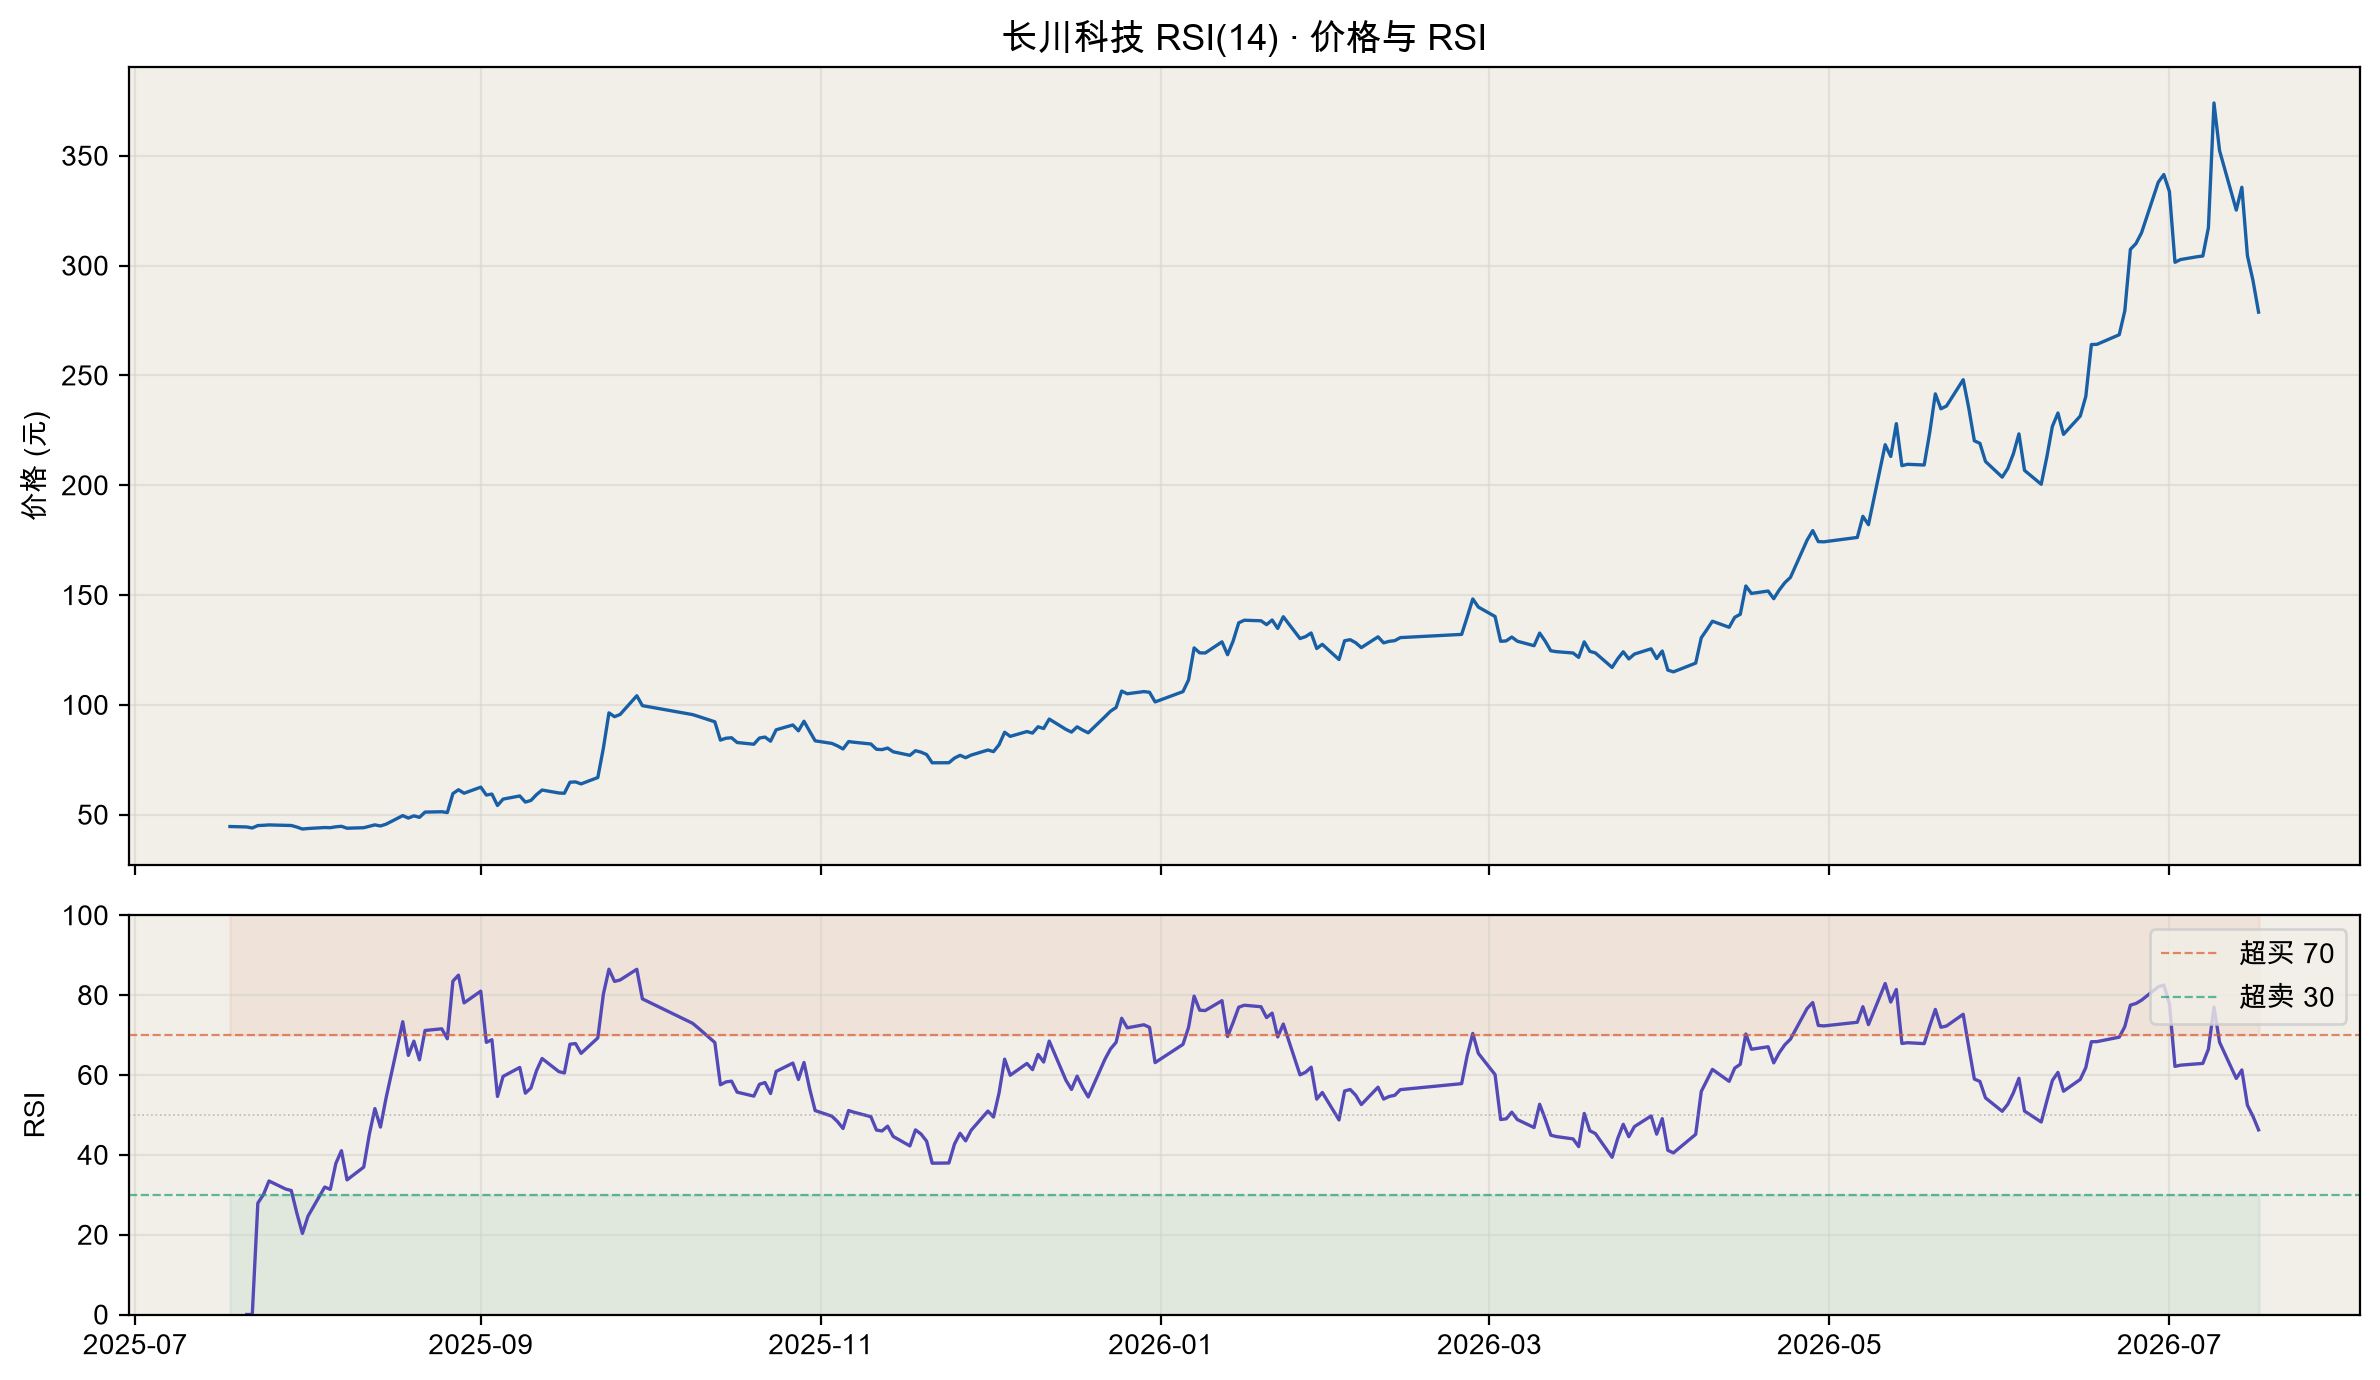

已保存: ../charts/01_rsi.png


In [7]:
# RSI 可视化: 价格上图 + RSI 下图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios':[2,1]})
# 价格
ax1.plot(df.index, df['close'], color=MID_COLOR, linewidth=1.2)
ax1.set_title(f'{NAME} RSI({PARAMS["rsi_period"]}) · 价格与 RSI', fontsize=13)
ax1.set_ylabel('价格 (元)')

# RSI
ax2.plot(df.index, df['rsi_14'], color=ACCENT, linewidth=1.2)
ax2.axhline(70, color=UP_COLOR, linestyle='--', linewidth=0.8, alpha=0.7, label='超买 70')
ax2.axhline(50, color='#888780', linestyle=':', linewidth=0.6, alpha=0.5)
ax2.axhline(30, color=DOWN_COLOR, linestyle='--', linewidth=0.8, alpha=0.7, label='超卖 30')
ax2.fill_between(df.index, 70, 100, alpha=0.08, color=UP_COLOR)
ax2.fill_between(df.index, 0, 30, alpha=0.08, color=DOWN_COLOR)
ax2.set_ylim(0, 100)
ax2.set_ylabel('RSI')
ax2.legend(loc='upper right', fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/01_rsi.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"已保存: {CHART_DIR}/01_rsi.png")


## Cell 6 — MACD 平滑异同移动平均线

**含义**: 用快慢均线的聚散捕捉趋势拐点。金叉 (DIF 上穿 DEA) 买入, 死叉卖出。

**公式 (EMA, 12/26/9)**:
1. $EMA_{fast} = EMA(close, 12)$, 用 `ewm(span=12, adjust=False)`, $\alpha = 2/13$
2. $EMA_{slow} = EMA(close, 26)$
3. $DIF = EMA_{fast} - EMA_{slow}$ (快线)
4. $DEA = EMA(DIF, 9)$ (慢线/信号线)
5. $hist = DIF - DEA$ (柱)

**关键决策 D1**: MACD 柱 **不乘 2** —— 与课程产品 spec 对齐。
- 经典文献写 $hist = 2(DIF - DEA)$, 但乘 2 只放大柱高, 不改变过零点。
- 不乘 2 让 hist 与 DIF/DEA 同量纲, 三者可同图比较。

**注意 EMA 参数区别**:
- MACD 的 EMA 用 `span=N` ($\alpha = 2/(N+1)$, 标准 EMA)
- RSI/ATR 的 Wilder 用 `alpha=1/n` ($\alpha = 1/n$, Wilder 衰减更慢)
- **两者概念不同**, 不混用。

In [8]:
# ============ MACD(12,26,9) 计算 ============
fast, slow, signal = PARAMS['macd_fast'], PARAMS['macd_slow'], PARAMS['macd_signal']
close = df['close']

ema_fast = close.ewm(span=fast, adjust=False).mean()
ema_slow = close.ewm(span=slow, adjust=False).mean()
dif = ema_fast - ema_slow
dea = dif.ewm(span=signal, adjust=False).mean()
hist = dif - dea   # ← 决策 D1: 不乘 2

df['macd_dif'] = dif
df['macd_dea'] = dea
df['macd_hist'] = hist
print(f"MACD 计算完成 (不乘 2, 见 D1)。DIF 前 {slow} 行为 warmup。")
df[['close','macd_dif','macd_dea','macd_hist']].tail()


MACD 计算完成 (不乘 2, 见 D1)。DIF 前 26 行为 warmup。


,close,macd_dif,macd_dea,macd_hist
trade_date,,,,
2026-07-13,325.24,28.028049,27.555490,0.472558
2026-07-14,335.62,27.144024,27.473197,-0.329173
2026-07-15,304.44,23.654785,26.709515,-3.054730
2026-07-16,293.13,19.749258,25.317463,-5.568205
2026-07-17,278.76,15.317985,23.317568,-7.999583


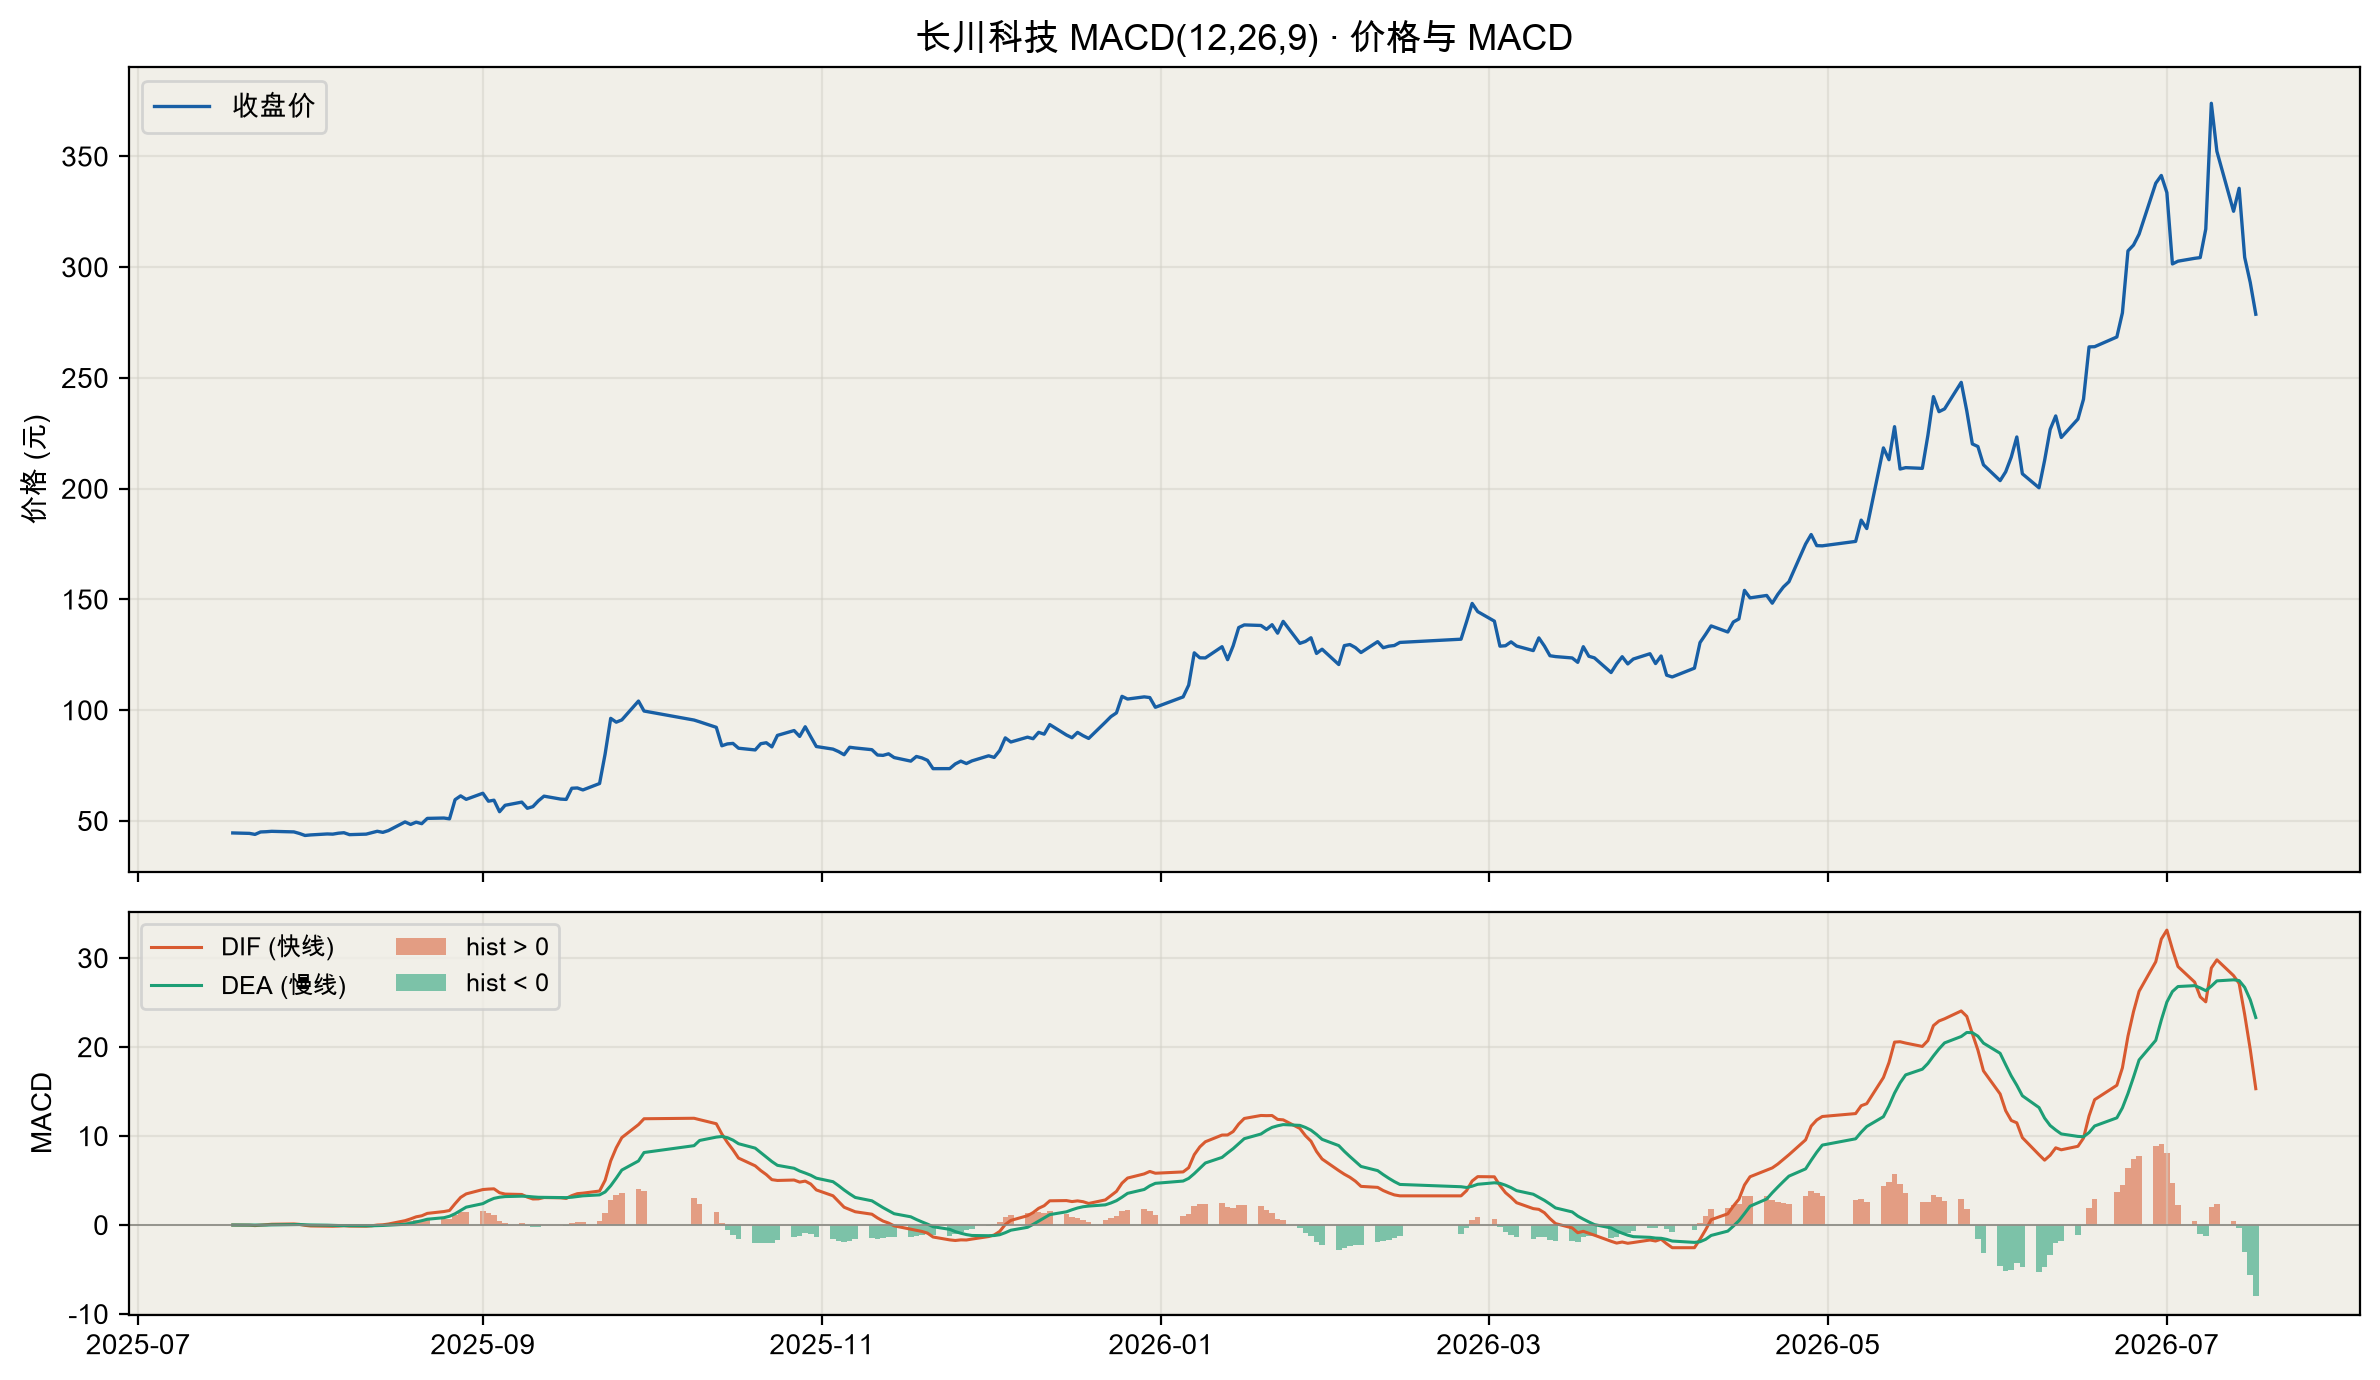

已保存: ../charts/02_macd.png


In [9]:
# MACD 可视化
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios':[2,1]})
ax1.plot(df.index, df['close'], color=MID_COLOR, linewidth=1.2, label='收盘价')
ax1.set_title(f'{NAME} MACD({fast},{slow},{signal}) · 价格与 MACD', fontsize=13)
ax1.set_ylabel('价格 (元)')
ax1.legend(loc='upper left', fontsize=10)

# DIF / DEA 线
ax2.plot(df.index, dif, color=UP_COLOR, linewidth=1.1, label='DIF (快线)')
ax2.plot(df.index, dea, color=DOWN_COLOR, linewidth=1.1, label='DEA (慢线)')
ax2.axhline(0, color='#888780', linewidth=0.6)
# hist 柱: 涨红跌绿
hist_pos = hist.clip(lower=0)
hist_neg = hist.clip(upper=0)
ax2.bar(df.index, hist_pos, color=UP_COLOR, alpha=0.55, width=1.0, label='hist > 0')
ax2.bar(df.index, hist_neg, color=DOWN_COLOR, alpha=0.55, width=1.0, label='hist < 0')
ax2.set_ylabel('MACD')
ax2.legend(loc='upper left', fontsize=9, ncol=2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/02_macd.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"已保存: {CHART_DIR}/02_macd.png")


## Cell 7 — 布林带 Bollinger Bands

**含义**: 波动率通道。中轨为 20 日均线, 上下轨 = 中轨 ± 2σ。通道随波动率伸缩。

**公式**:
1. $BB_{mid} = SMA(close, 20)$
2. $\sigma = \text{std}(close, 20)$
3. $BB_{upper} = BB_{mid} + 2\sigma$; $BB_{lower} = BB_{mid} - 2\sigma$
4. $BB_{width} = (upper - lower) / mid$
5. $\%B = (close - lower) / (upper - lower)$

**关键决策 D3**: $\sigma$ 用 `ddof=0` (总体标准差)。
- pandas `.std()` 默认 `ddof=1` (样本标准差, 除以 N−1), 会偏大。
- Bollinger 原版用总体标准差 (除以 N), 对齐原版避免与交易软件结果偏差。
- 写法: `close.rolling(20).std(ddof=0)`。

In [10]:
# ============ 布林带(20, 2σ) 计算 ============
w, k = PARAMS['bb_window'], PARAMS['bb_std']
close = df['close']

bb_mid = close.rolling(w).mean()
sigma = close.rolling(w).std(ddof=0)   # ← 决策 D3: 总体标准差
bb_upper = bb_mid + k * sigma
bb_lower = bb_mid - k * sigma
bb_width = (bb_upper - bb_lower) / bb_mid
pct_b = (close - bb_lower) / (bb_upper - bb_lower)

df['bb_mid'] = bb_mid
df['bb_upper'] = bb_upper
df['bb_lower'] = bb_lower
df['bb_width'] = bb_width
df['bb_pct_b'] = pct_b
print(f"布林带计算完成 (ddof=0, 见 D3)。前 {w} 行为 warmup。")
df[['close','bb_mid','bb_upper','bb_lower','bb_width','bb_pct_b']].tail()


布林带计算完成 (ddof=0, 见 D3)。前 20 行为 warmup。


,close,bb_mid,bb_upper,bb_lower,bb_width,bb_pct_b
trade_date,,,,,,
2026-07-13,325.24,303.7175,375.589429,231.845571,0.473281,0.649728
2026-07-14,335.62,308.9260,373.857471,243.994529,0.420369,0.705555
2026-07-15,304.44,312.1280,369.048533,255.207467,0.364726,0.432467
2026-07-16,293.13,313.5840,366.881127,260.286873,0.339922,0.308113
2026-07-17,278.76,314.3170,365.221258,263.412742,0.323904,0.150746


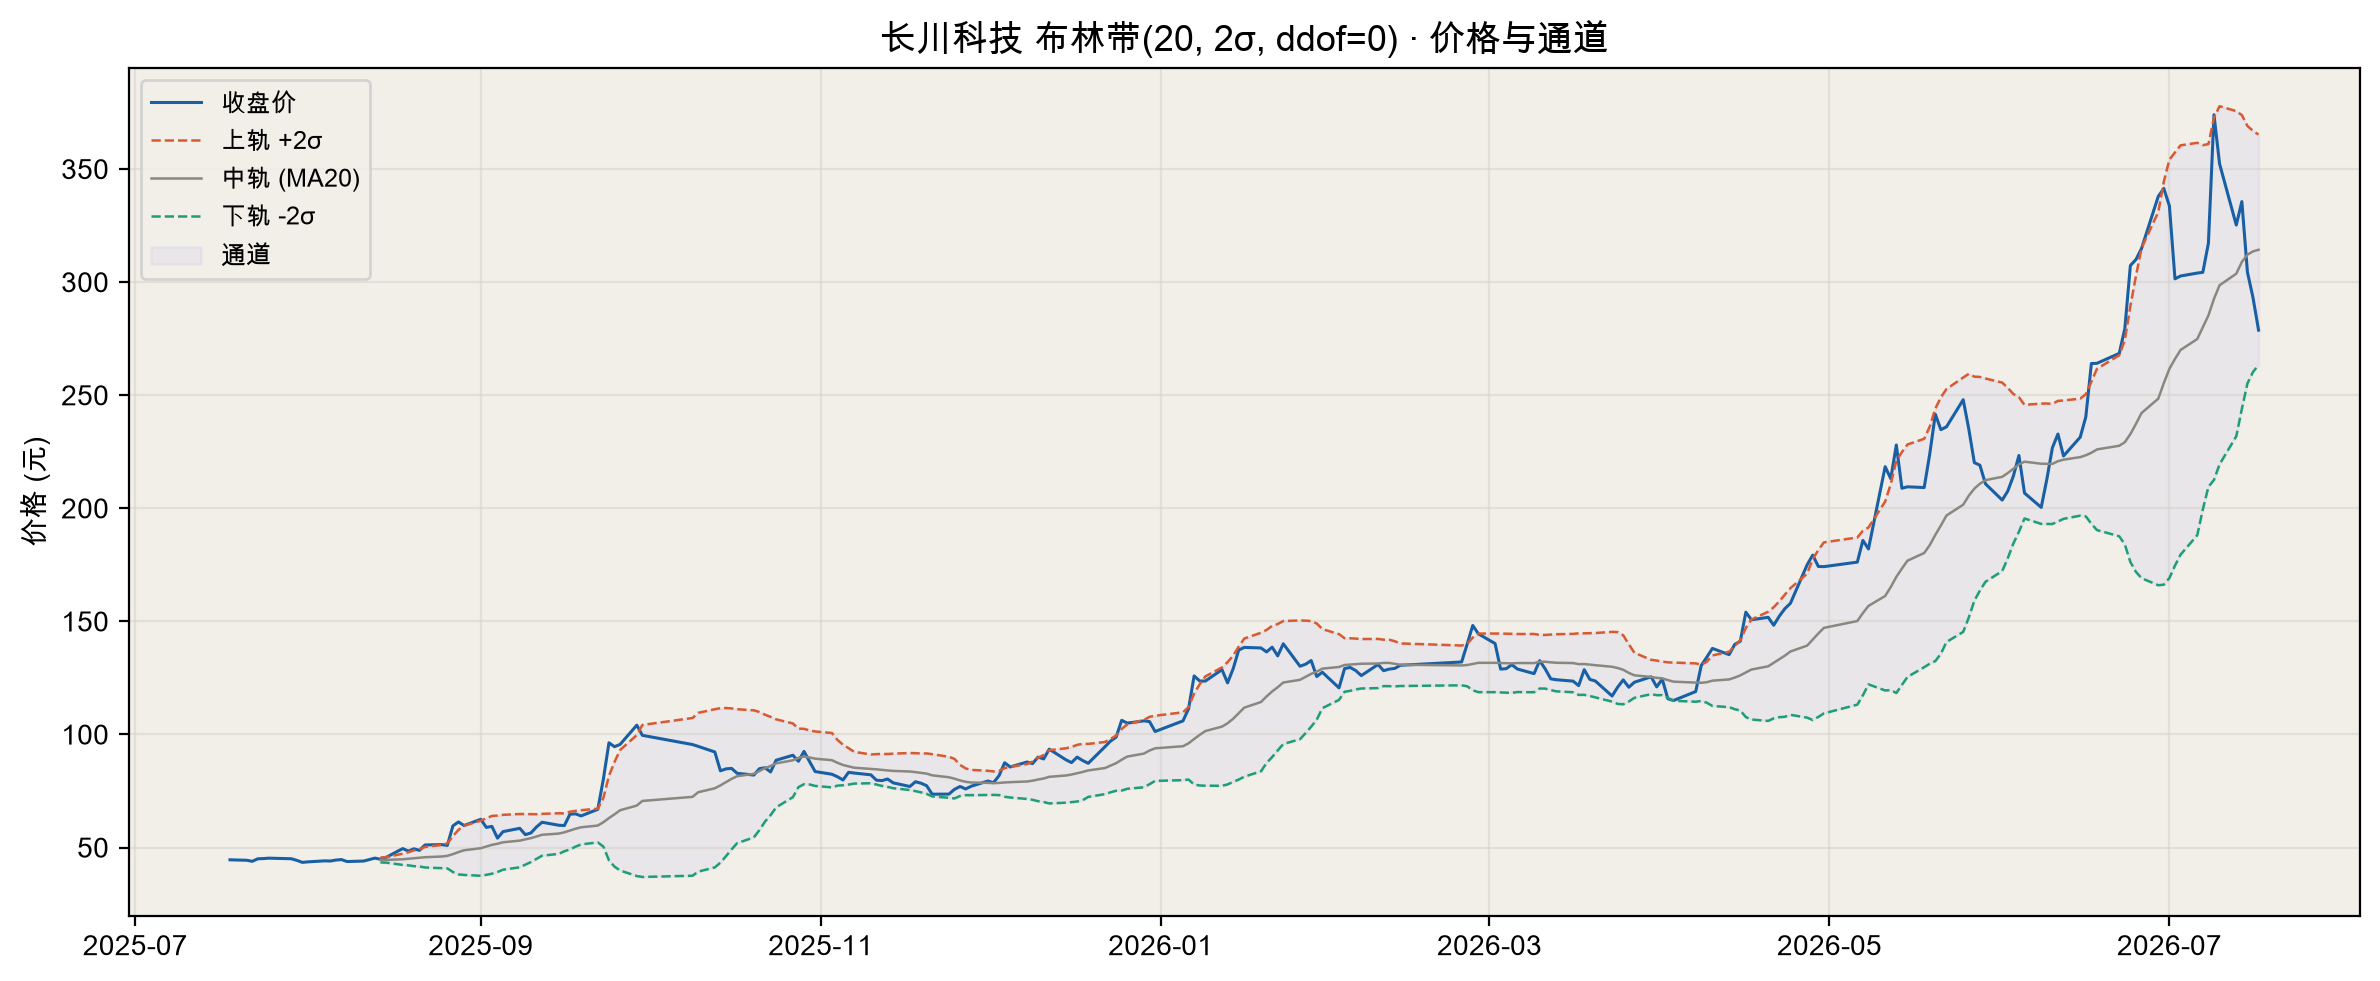

已保存: ../charts/03_bollinger.png


In [11]:
# 布林带可视化
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df['close'], color=MID_COLOR, linewidth=1.1, label='收盘价')
ax.plot(df.index, bb_upper, color=UP_COLOR, linewidth=0.9, linestyle='--', label='上轨 +2σ')
ax.plot(df.index, bb_mid, color='#888780', linewidth=0.9, label='中轨 (MA20)')
ax.plot(df.index, bb_lower, color=DOWN_COLOR, linewidth=0.9, linestyle='--', label='下轨 -2σ')
ax.fill_between(df.index, bb_lower, bb_upper, alpha=0.12, color=BAND_COLOR, label='通道')
ax.set_title(f'{NAME} 布林带({w}, {k}σ, ddof=0) · 价格与通道', fontsize=13)
ax.set_ylabel('价格 (元)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/03_bollinger.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"已保存: {CHART_DIR}/03_bollinger.png")


## Cell 8 — ATR 真实波动幅度均值

**含义**: 纯波动率指标, 不预测方向, 只回答"平均每天蹦多大"。是止损/仓位管理的核心工具。

**公式 (Wilder smoothing)**:
1. 真实波幅 $TR_t = \max($当日振幅, 跳空高开, 跳空低开$)$:
   - $H_t - L_t$
   - $|H_t - close_{t-1}|$
   - $|L_t - close_{t-1}|$
2. $ATR = $ Wilder 平滑 of TR, $\alpha = 1/14$

**关键决策 D2**: 与 RSI 一致, Wilder 平滑用 `ewm(alpha=1/n, adjust=False)`。

**用途提示 (notebook 不实现)**:
- 止损距离常设 $1.5 \sim 3 \times ATR$
- 仓位 = 单笔风险金额 / (ATR × 倍数)

In [12]:
# ============ ATR(14) 计算 ============
n = PARAMS['atr_period']
high, low, pre_close = df['high'], df['low'], df['pre_close']

# 真实波幅 TR
tr1 = high - low
tr2 = (high - pre_close).abs()
tr3 = (low - pre_close).abs()
tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

# Wilder smoothing: ewm(alpha=1/n)  ← 决策 D2
atr = tr.ewm(alpha=1/n, adjust=False).mean()

df['tr'] = tr
df['atr_14'] = atr
print(f"ATR 计算完成 (Wilder, alpha=1/{n})。首行 TR 用 high-low (无前收概念由 pre_close 提供)。")
print(f"ATR 有效值范围: [{atr.min():.2f}, {atr.max():.2f}] 元")
df[['high','low','pre_close','tr','atr_14']].tail()


ATR 计算完成 (Wilder, alpha=1/14)。首行 TR 用 high-low (无前收概念由 pre_close 提供)。
ATR 有效值范围: [0.80, 29.74] 元


,high,low,pre_close,tr,atr_14
trade_date,,,,,
2026-07-13,358.88,320.15,352.31,38.73,28.820979
2026-07-14,341.50,312.01,325.24,29.49,28.868766
2026-07-15,344.02,303.00,335.62,41.02,29.736711
2026-07-16,309.97,288.00,304.44,21.97,29.181946
2026-07-17,297.00,273.57,293.13,23.43,28.771093


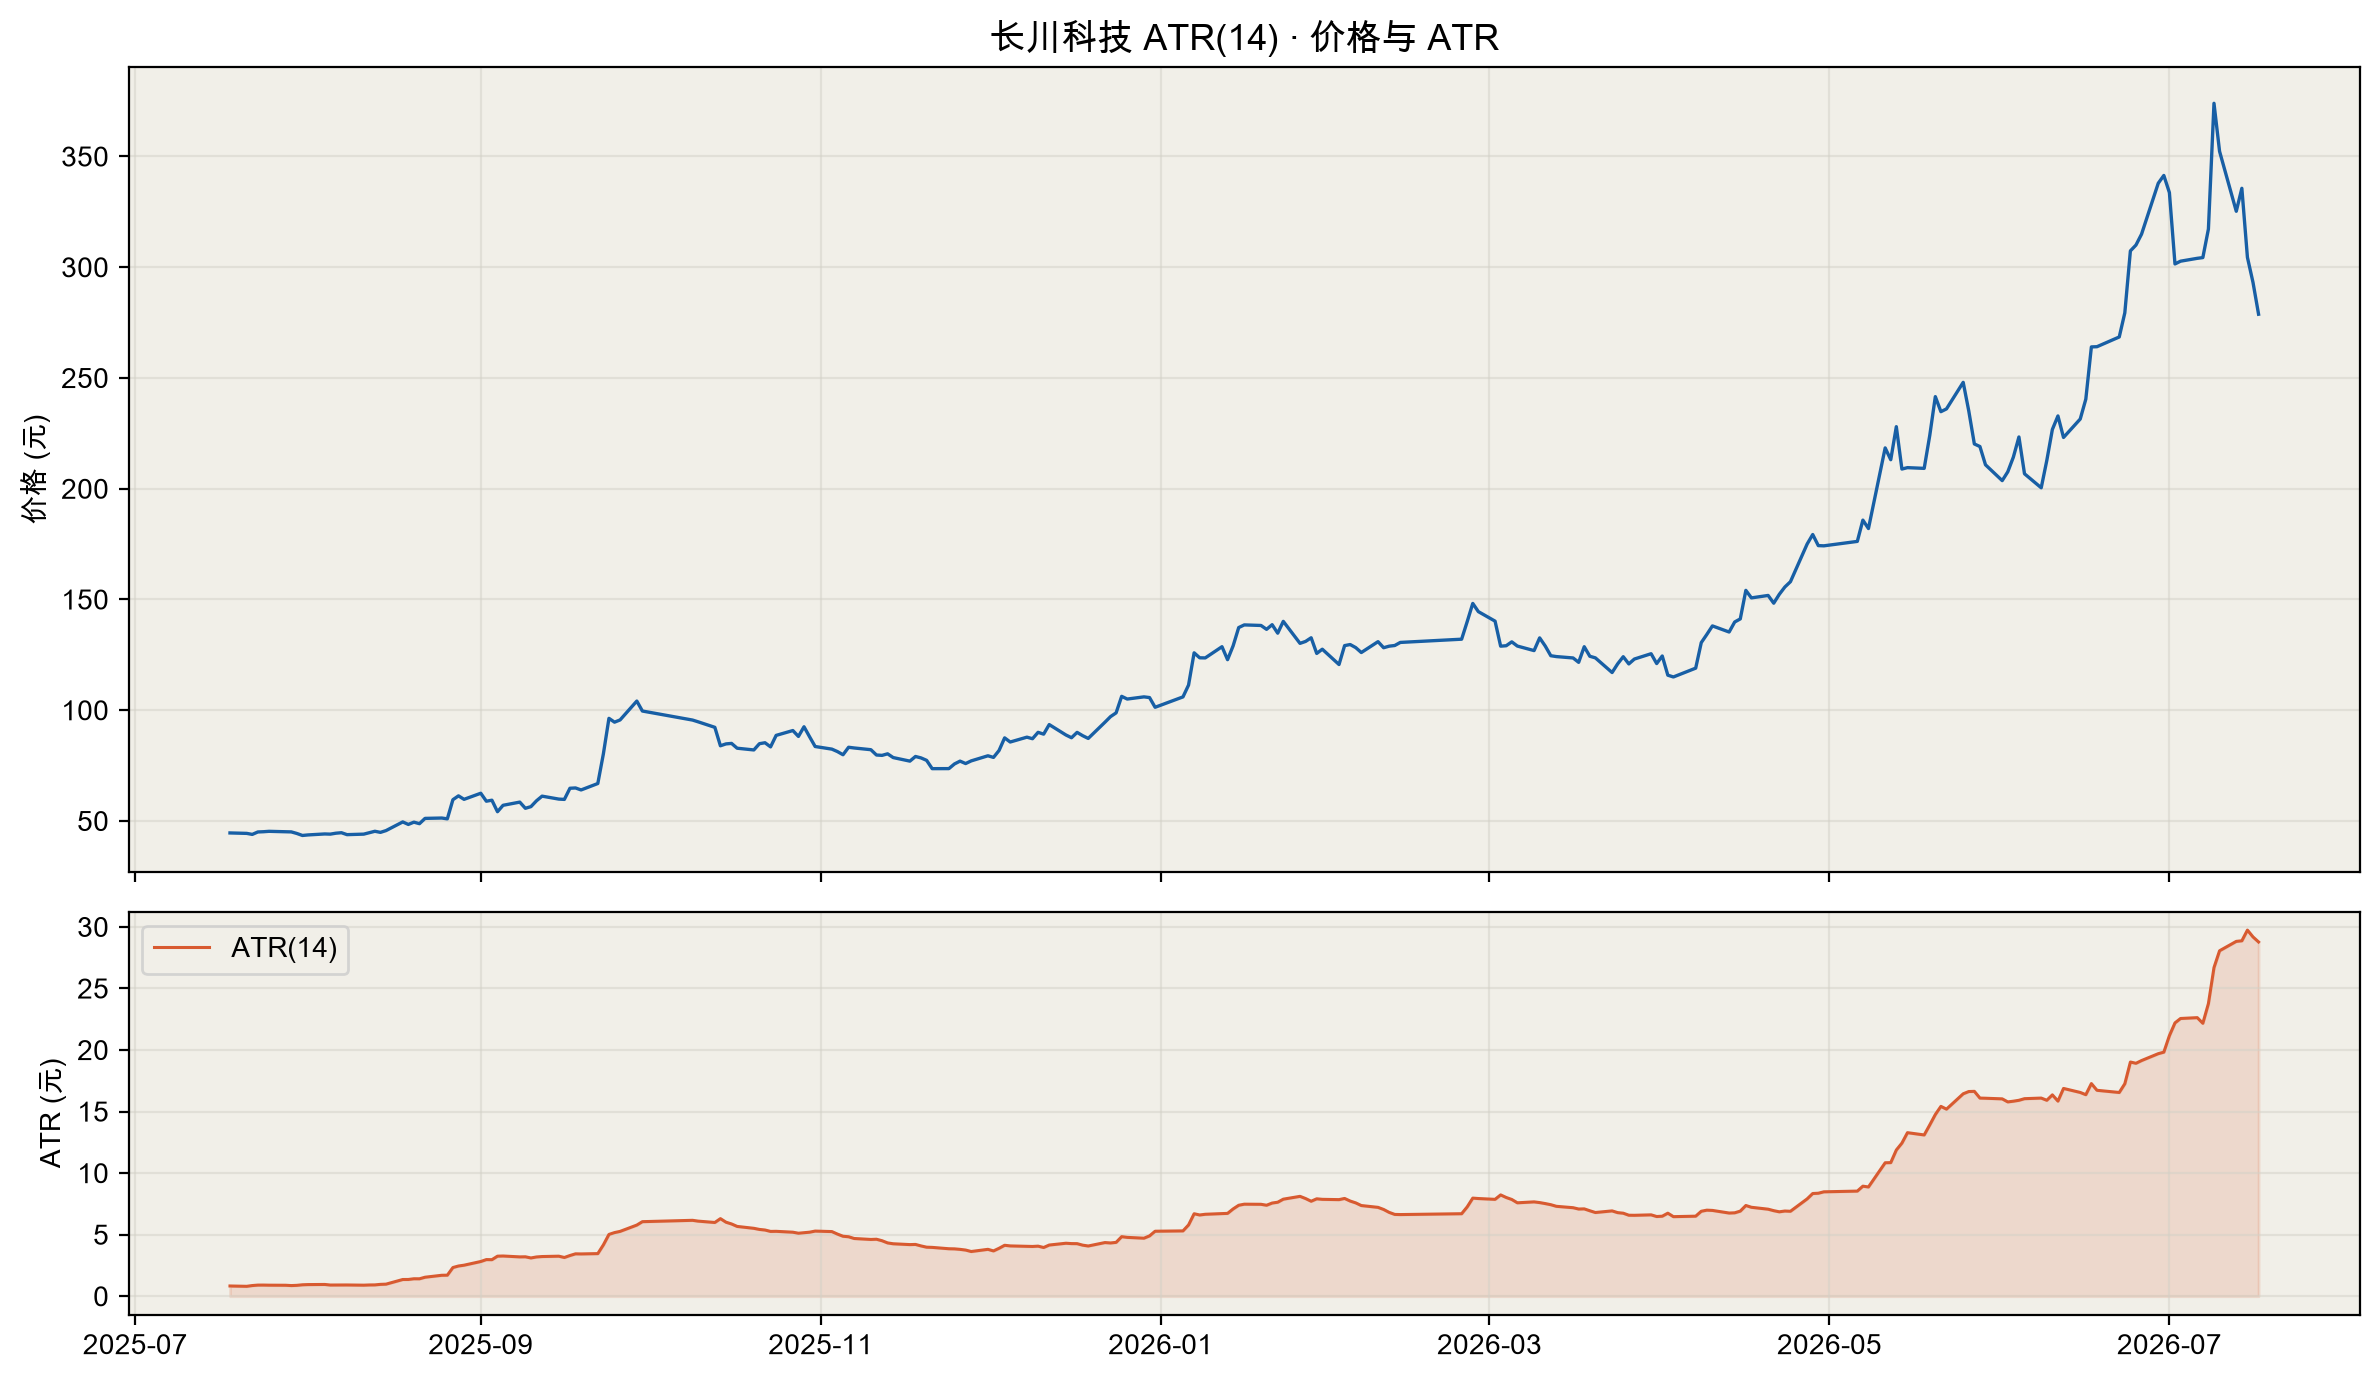

已保存: ../charts/04_atr.png


In [13]:
# ATR 可视化
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios':[2,1]})
ax1.plot(df.index, df['close'], color=MID_COLOR, linewidth=1.2)
ax1.set_title(f'{NAME} ATR({PARAMS["atr_period"]}) · 价格与 ATR', fontsize=13)
ax1.set_ylabel('价格 (元)')

ax2.plot(df.index, atr, color=UP_COLOR, linewidth=1.1, label='ATR(14)')
ax2.fill_between(df.index, 0, atr, alpha=0.15, color=UP_COLOR)
ax2.set_ylabel('ATR (元)')
ax2.legend(loc='upper left', fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/04_atr.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"已保存: {CHART_DIR}/04_atr.png")


## Cell 9 — 综合可视化 (四指标横向对比)

2×2 子图共享时间轴, 一眼看清四指标在同一周期的表现。

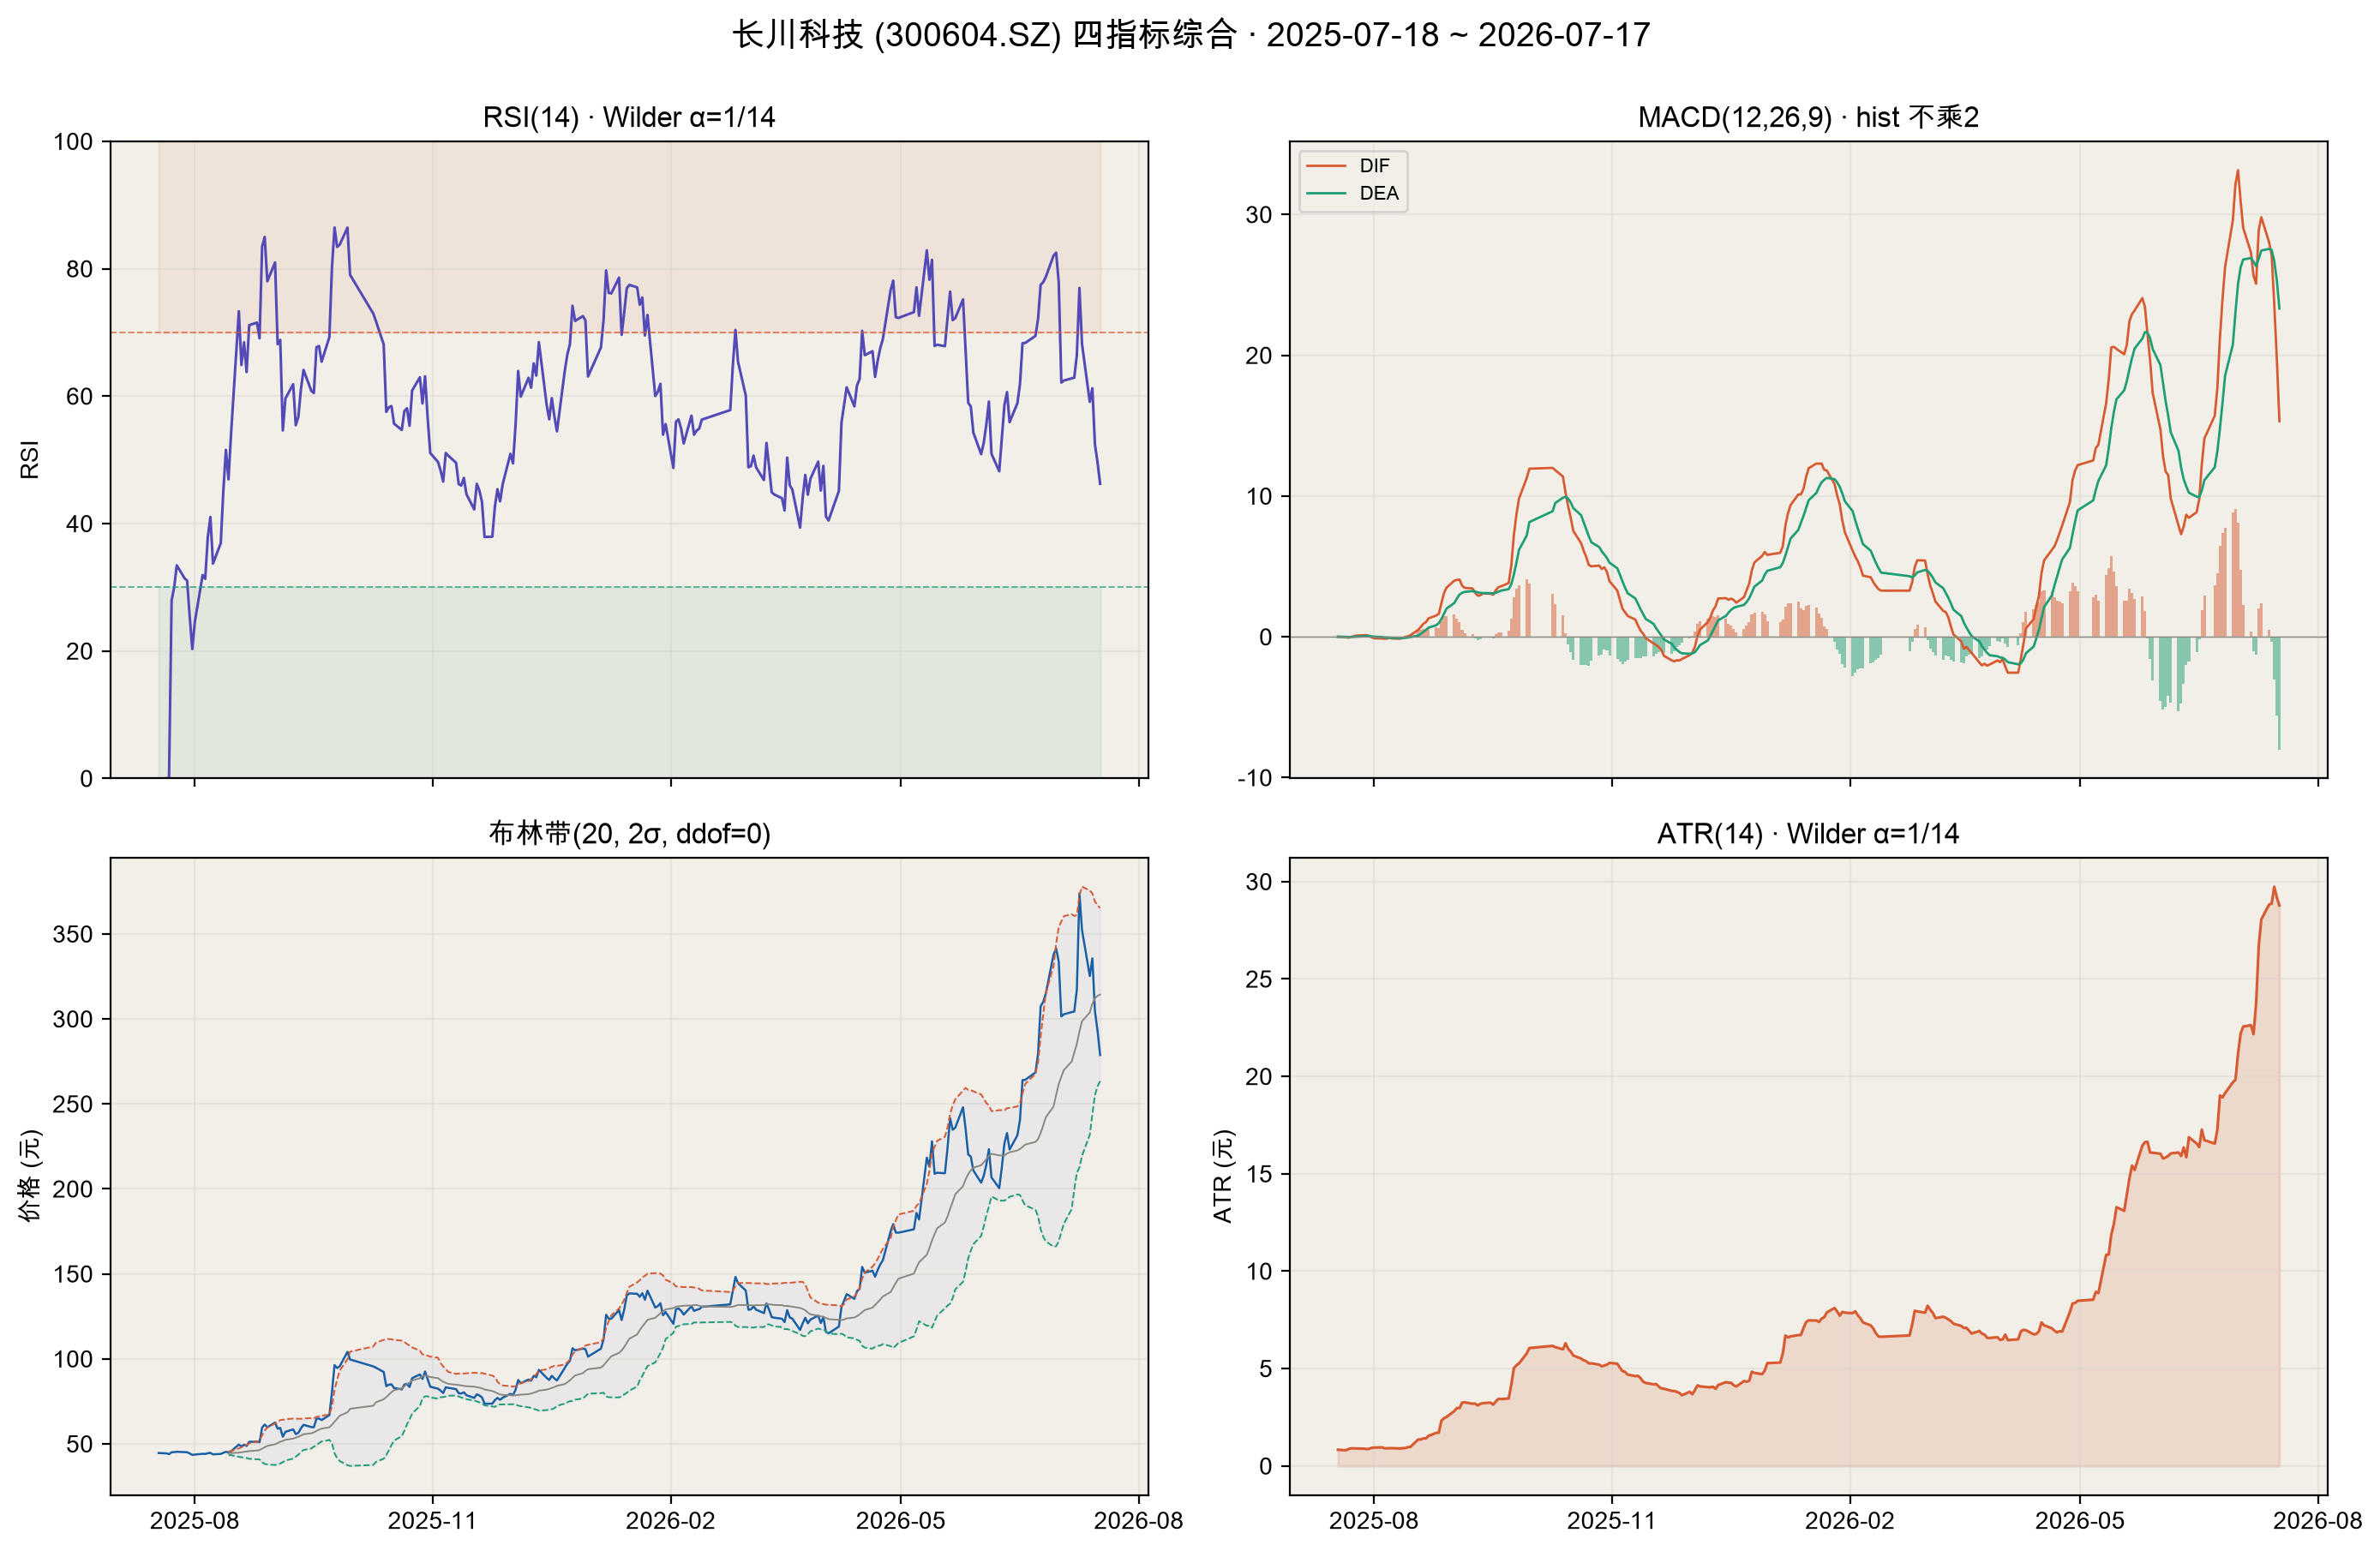

已保存: ../charts/05_overview.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
ax = axes.ravel()

# 1. RSI
ax[0].plot(df.index, df['rsi_14'], color=ACCENT, linewidth=1.1)
ax[0].axhline(70, color=UP_COLOR, ls='--', lw=0.7, alpha=0.7)
ax[0].axhline(30, color=DOWN_COLOR, ls='--', lw=0.7, alpha=0.7)
ax[0].fill_between(df.index, 70, 100, alpha=0.08, color=UP_COLOR)
ax[0].fill_between(df.index, 0, 30, alpha=0.08, color=DOWN_COLOR)
ax[0].set_ylim(0, 100)
ax[0].set_title(f'RSI({PARAMS["rsi_period"]}) · Wilder α=1/{PARAMS["rsi_period"]}', fontsize=12)
ax[0].set_ylabel('RSI')

# 2. MACD
ax[1].plot(df.index, df['macd_dif'], color=UP_COLOR, linewidth=1, label='DIF')
ax[1].plot(df.index, df['macd_dea'], color=DOWN_COLOR, linewidth=1, label='DEA')
ax[1].bar(df.index, df['macd_hist'].clip(lower=0), color=UP_COLOR, alpha=0.5, width=1)
ax[1].bar(df.index, df['macd_hist'].clip(upper=0), color=DOWN_COLOR, alpha=0.5, width=1)
ax[1].axhline(0, color='#888780', lw=0.5)
ax[1].set_title(f'MACD({PARAMS["macd_fast"]},{PARAMS["macd_slow"]},{PARAMS["macd_signal"]}) · hist 不乘2', fontsize=12)
ax[1].legend(loc='upper left', fontsize=8)

# 3. 布林带 (价格 + 通道)
ax[2].plot(df.index, df['close'], color=MID_COLOR, linewidth=0.9, label='close')
ax[2].plot(df.index, df['bb_upper'], color=UP_COLOR, linewidth=0.7, ls='--')
ax[2].plot(df.index, df['bb_mid'], color='#888780', linewidth=0.7)
ax[2].plot(df.index, df['bb_lower'], color=DOWN_COLOR, linewidth=0.7, ls='--')
ax[2].fill_between(df.index, df['bb_lower'], df['bb_upper'], alpha=0.1, color=BAND_COLOR)
ax[2].set_title(f'布林带({PARAMS["bb_window"]}, {PARAMS["bb_std"]}σ, ddof=0)', fontsize=12)
ax[2].set_ylabel('价格 (元)')

# 4. ATR
ax[3].plot(df.index, df['atr_14'], color=UP_COLOR, linewidth=1.1)
ax[3].fill_between(df.index, 0, df['atr_14'], alpha=0.15, color=UP_COLOR)
ax[3].set_title(f'ATR({PARAMS["atr_period"]}) · Wilder α=1/{PARAMS["atr_period"]}', fontsize=12)
ax[3].set_ylabel('ATR (元)')

for a in ax:
    a.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    a.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    a.grid(True, alpha=0.4)

fig.suptitle(f'{NAME} ({TS_CODE}) 四指标综合 · {df.index[0].date()} ~ {df.index[-1].date()}', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/05_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"已保存: {CHART_DIR}/05_overview.png")


## Cell 10 — 输出保存与验收检查

输出:
- `outputs/changchuan_indicators.csv` — 含全部指标列的表
- 5 张 PNG 图表 (已在上方保存)

验收 (见 spec 第 7 节 A1-A9):

In [15]:
# ============ 输出 CSV ============
out_cols = ['open','high','low','close','pct_chg',
            'rsi_14','macd_dif','macd_dea','macd_hist',
            'bb_mid','bb_upper','bb_lower','bb_width','bb_pct_b',
            'tr','atr_14']
out_df = df[out_cols].copy()
out_df.index = out_df.index.strftime('%Y%m%d')
out_df.index.name = 'trade_date'
out_csv = f'{OUTPUT_DIR}/changchuan_indicators.csv'
out_df.to_csv(out_csv, encoding='utf-8-sig')
print(f"已保存: {out_csv} ({len(out_df)} 行, {len(out_cols)} 列)")

# ============ 验收检查 ============
print()
print("=== 验收检查 (spec A1-A9) ===")
# A2: warmup 期内允许 NaN, warmup 后无 NaN
warmup = max(PARAMS['rsi_period'], PARAMS['macd_slow'], PARAMS['bb_window'], PARAMS['atr_period']) + 2
post_warmup = out_df.iloc[warmup:]
nan_after = post_warmup.isna().sum().sum()
print(f"A2 warmup={warmup} 行; warmup 后 NaN 数: {nan_after}  {'PASS' if nan_after==0 else 'FAIL'}")
# A3: RSI in [0,100]
rsi_valid = out_df['rsi_14'].dropna()
a3 = rsi_valid.between(0,100).all()
print(f"A3 RSI in [0,100]: {a3}  {'PASS' if a3 else 'FAIL'}")
# A4: ATR >= 0
a4 = (out_df['atr_14'].dropna() >= 0).all()
print(f"A4 ATR >= 0: {a4}  {'PASS' if a4 else 'FAIL'}")
# A5: bb_upper >= bb_mid >= bb_lower
bb_valid = out_df[['bb_upper','bb_mid','bb_lower']].dropna()
a5 = ((bb_valid['bb_upper'] >= bb_valid['bb_mid']) & (bb_valid['bb_mid'] >= bb_valid['bb_lower'])).all()
print(f"A5 bb_upper>=mid>=lower: {a5}  {'PASS' if a5 else 'FAIL'}")
# A6: macd_hist = dif - dea (不乘2)
a6 = np.allclose(out_df['macd_dif'] - out_df['macd_dea'], out_df['macd_hist'], atol=1e-6, equal_nan=True)
print(f"A6 hist = dif-dea (不乘2): {a6}  {'PASS' if a6 else 'FAIL'}")
# A7: 行数一致
a7 = len(out_df) == len(df)
print(f"A7 输出行数={len(out_df)} == 输入{len(df)}: {a7}  {'PASS' if a7 else 'FAIL'}")
# A8: 5张图存在
charts = [f'{CHART_DIR}/01_rsi.png', f'{CHART_DIR}/02_macd.png', f'{CHART_DIR}/03_bollinger.png',
          f'{CHART_DIR}/04_atr.png', f'{CHART_DIR}/05_overview.png']
a8 = all(os.path.exists(c) for c in charts)
print(f"A8 5张PNG均存在: {a8}  {'PASS' if a8 else 'FAIL'}")
print(f"A9 中文显示: 肉眼检查上方图表")

all_pass = all([nan_after==0, a3, a4, a5, a6, a7, a8])
print()
print(f"=== 验收总览: {'ALL PASS' if all_pass else 'SOME FAIL'} ===")

out_df.tail()


已保存: ../outputs/changchuan_indicators.csv (242 行, 16 列)

=== 验收检查 (spec A1-A9) ===
A2 warmup=28 行; warmup 后 NaN 数: 0  PASS
A3 RSI in [0,100]: True  PASS
A4 ATR >= 0: True  PASS
A5 bb_upper>=mid>=lower: True  PASS
A6 hist = dif-dea (不乘2): True  PASS
A7 输出行数=242 == 输入242: True  PASS
A8 5张PNG均存在: True  PASS
A9 中文显示: 肉眼检查上方图表

=== 验收总览: ALL PASS ===


,open,high,low,close,pct_chg,rsi_14,macd_dif,macd_dea,macd_hist,bb_mid,bb_upper,bb_lower,bb_width,bb_pct_b,tr,atr_14
trade_date,,,,,,,,,,,,,,,,
20260713,352.13,358.88,320.15,325.24,-7.6836,59.102865,28.028049,27.555490,0.472558,303.7175,375.589429,231.845571,0.473281,0.649728,38.73,28.820979
20260714,332.00,341.50,312.01,335.62,3.1915,61.233863,27.144024,27.473197,-0.329173,308.9260,373.857471,243.994529,0.420369,0.705555,29.49,28.868766
20260715,344.00,344.02,303.00,304.44,-9.2903,52.401145,23.654785,26.709515,-3.054730,312.1280,369.048533,255.207467,0.364726,0.432467,41.02,29.736711
20260716,303.05,309.97,288.00,293.13,-3.7150,49.605977,19.749258,25.317463,-5.568205,313.5840,366.881127,260.286873,0.339922,0.308113,21.97,29.181946
20260717,291.89,297.00,273.57,278.76,-4.9023,46.231664,15.317985,23.317568,-7.999583,314.3170,365.221258,263.412742,0.323904,0.150746,23.43,28.771093
